In [7]:
# TASK 5: SALES DATA ANALYSIS

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
# STEP 1: LOAD DATASET
df = pd.read_csv("D:\PenDrive\Syn Internship\synent-task5-salesanalysis-demo\synent-task5-salesanalysis-demo\data\SuperStoreOrders.csv")

print("First 5 Rows:")
print(df.head())

First 5 Rows:
          order_id order_date ship_date       ship_mode    customer_name  \
0     AG-2011-2040   1/1/2011  6/1/2011  Standard Class  Toby Braunhardt   
1    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   
2     HU-2011-1220   1/1/2011  5/1/2011    Second Class    Annie Thurman   
3  IT-2011-3647632   1/1/2011  5/1/2011    Second Class     Eugene Moren   
4    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

          category sub_category                 product_name sales quantity  \
0  Office Supplies      Storage          

In [12]:
#STEP 2: BASIC INFORMATION
print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape:
(51290, 21)

Columns:
Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

Missing Values:
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64


In [17]:
# STEP 4: DATA CLEANING

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert order_date column to datetime
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='mixed',
    dayfirst=True
)

# Create Month-Year column
df['month_year'] = df['order_date'].dt.to_period('M')

print("\nData Cleaning Completed Successfully")


Data Cleaning Completed Successfully


In [19]:
# Convert sales column to numeric
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

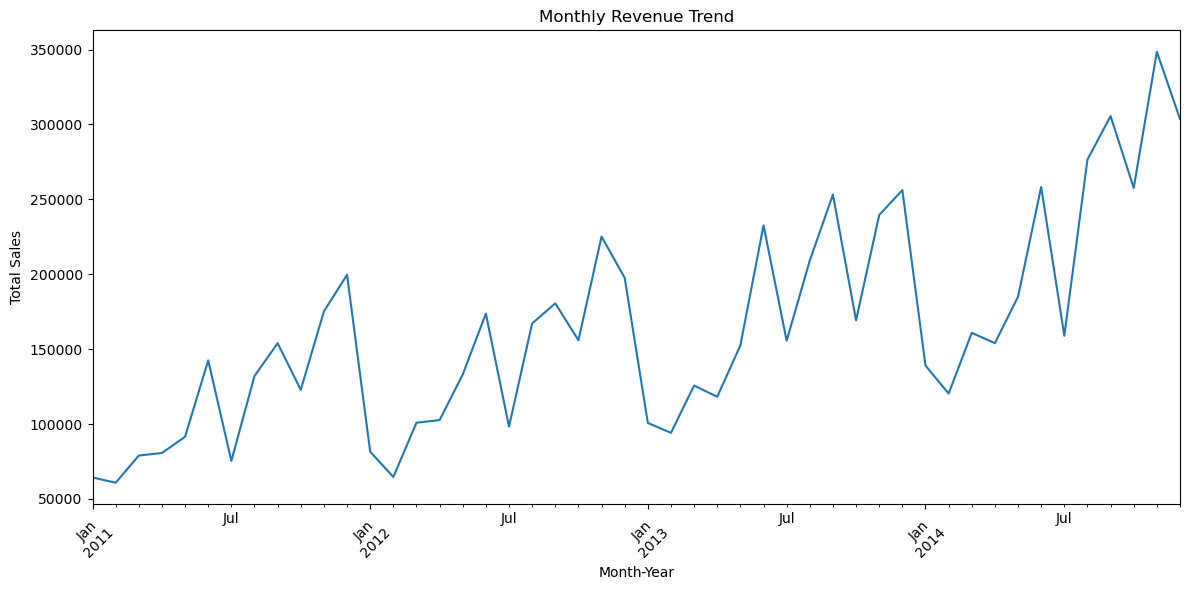

In [20]:
# STEP 5: MONTHLY REVENUE TRENDS

# Convert sales column to numeric
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

monthly_sales = df.groupby('month_year')['sales'].sum()

plt.figure(figsize=(12,6))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month-Year")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("monthly_revenue_trend.png")

plt.show()

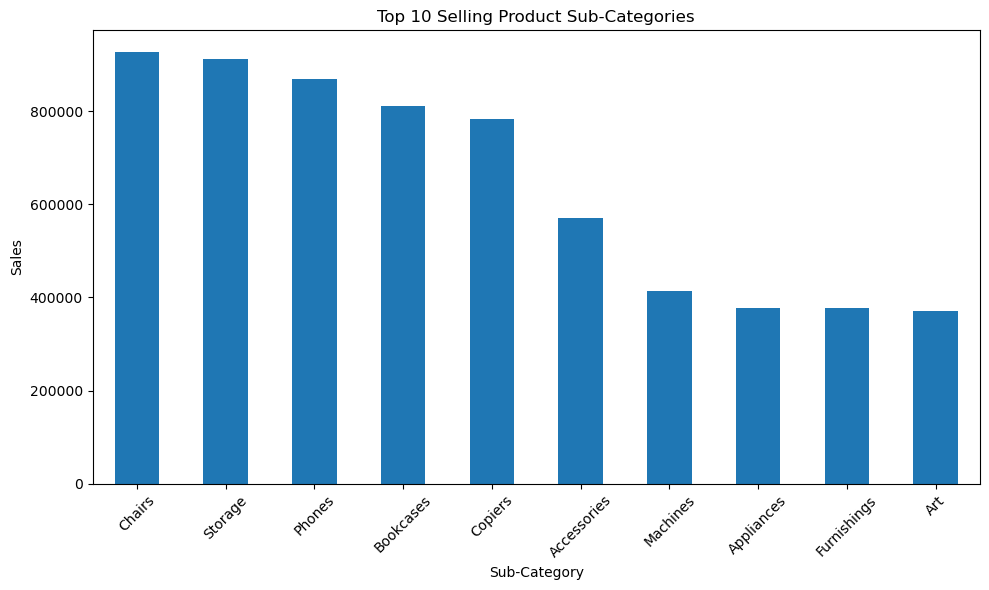


Top Selling Products:
sub_category
Chairs         927982.0
Storage        913499.0
Phones         870518.0
Bookcases      811505.0
Copiers        782710.0
Accessories    570054.0
Machines       414983.0
Appliances     377590.0
Furnishings    377432.0
Art            371050.0
Name: sales, dtype: float64


In [21]:
# STEP 6: TOP-SELLING PRODUCTS

top_products = (
    df.groupby('sub_category')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_products.plot(kind='bar')

plt.title("Top 10 Selling Product Sub-Categories")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("top_selling_products.png")

plt.show()

print("\nTop Selling Products:")
print(top_products)


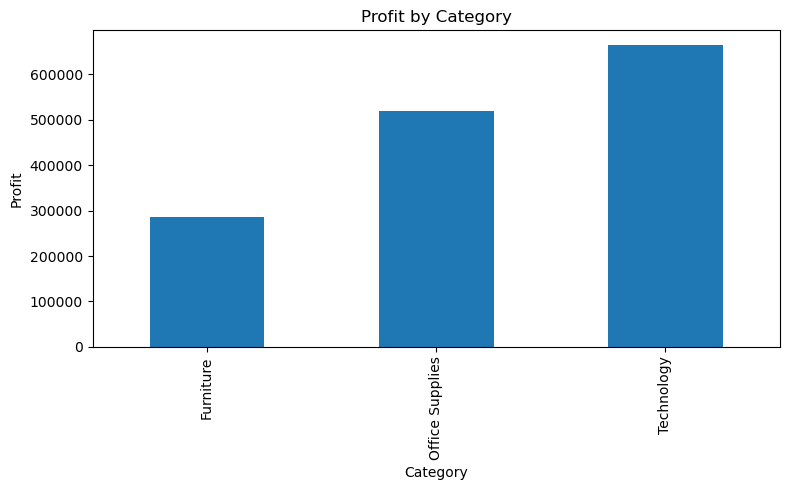


Profit by Category:
category
Furniture          286782.25380
Office Supplies    518473.83430
Technology         663778.73318
Name: profit, dtype: float64


In [22]:
# STEP 7: PROFIT ANALYSIS BY CATEGORY


category_profit = df.groupby('category')['profit'].sum()

plt.figure(figsize=(8,5))

category_profit.plot(kind='bar')

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()

plt.savefig("profit_by_category.png")

plt.show()

print("\nProfit by Category:")
print(category_profit)


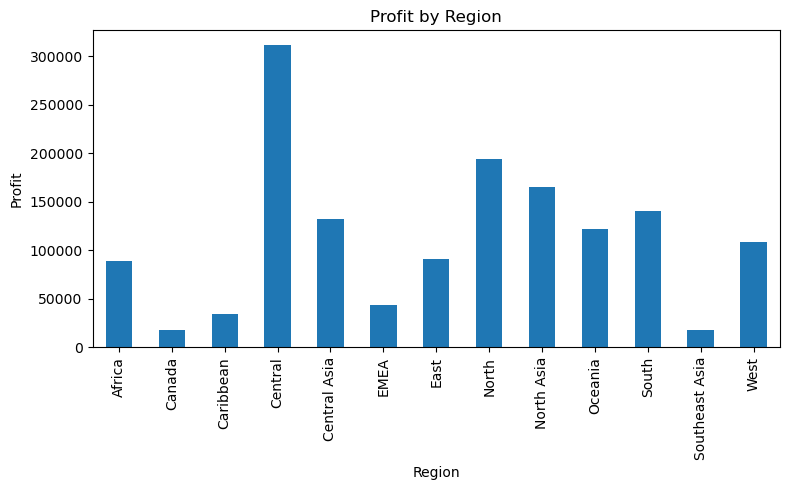


Profit by Region:
region
Africa             88871.63100
Canada             17817.39000
Caribbean          34571.32104
Central           311403.98164
Central Asia      132480.18700
EMEA               43897.97100
East               91522.78000
North             194597.95252
North Asia        165578.42100
Oceania           121666.64200
South             140355.76618
Southeast Asia     17852.32900
West              108418.44890
Name: profit, dtype: float64


In [23]:
# STEP 8: PROFIT ANALYSIS BY REGION
region_profit = df.groupby('region')['profit'].sum()

plt.figure(figsize=(8,5))

region_profit.plot(kind='bar')

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.tight_layout()

plt.savefig("profit_by_region.png")

plt.show()

print("\nProfit by Region:")
print(region_profit)


In [24]:
# STEP 9: BUSINESS INSIGHTS REPORT

print("\n================================================")
print("BUSINESS INSIGHTS REPORT")
print("================================================")

print("1. Monthly sales trends help identify peak business periods.")

print("2. Top-selling sub-categories contribute significantly to total revenue.")

print("3. Profit analysis helps identify the most profitable categories.")

print("4. Region-wise profit analysis helps identify better-performing markets.")

print("5. Some categories generate high sales but lower profit margins.")

print("6. Business can improve performance by focusing on profitable products and regions.")


# STEP 10: FINAL CONCLUSION


print("\nConclusion:")
print("This project successfully analyzed sales and profit performance")
print("using the Superstore Sales Dataset and generated useful business insights.")


BUSINESS INSIGHTS REPORT
1. Monthly sales trends help identify peak business periods.
2. Top-selling sub-categories contribute significantly to total revenue.
3. Profit analysis helps identify the most profitable categories.
4. Region-wise profit analysis helps identify better-performing markets.
5. Some categories generate high sales but lower profit margins.
6. Business can improve performance by focusing on profitable products and regions.

Conclusion:
This project successfully analyzed sales and profit performance
using the Superstore Sales Dataset and generated useful business insights.
